# BTC Volatility Transformer - Part 3: Trading Strategy Backtest

**Prerequisites**: Run Parts 1 and 2 first to generate data and train the model.

**This Notebook**: Backtest a "Volatility Surprise Momentum" strategy using our transformer's predictions.

---

## Learning Objectives

By the end of this notebook, you'll understand:
- How to convert volatility predictions into trading signals
- Backtesting mechanics (entry, exit, position tracking)
- The impact of bid-ask spreads on strategy performance
- Key performance metrics (Sharpe, drawdown, win rate)
- How to evaluate whether a model adds value vs random signals

---

## Strategy Overview: Volatility Surprise Momentum

**Core Idea**: When the model predicts volatility different from current observations, expect a move and trade with momentum.

```
volatility_surprise = predicted_vol / realized_vol

If surprise > 1.1 AND momentum up   → LONG (expect big up move)
If surprise > 1.1 AND momentum down → SHORT (expect big down move)
If 0.9 ≤ surprise ≤ 1.1             → NO TRADE (model agrees with market)
```

---
## Section 1: Setup and Load Model

In [ ]:
# =============================================================================
# STEP 1.1: Mount Google Drive
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/btc_volatility_project'
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/btc_volatility_project


In [ ]:
# =============================================================================
# STEP 1.2: Imports
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# =============================================================================
# STEP 1.3: Rebuild model architecture (same as Part 2)
# =============================================================================

# We need to define the model classes before loading weights

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    attention_weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, V)
    return output, attention_weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        attn_output, _ = scaled_dot_product_attention(Q, K, V, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_o(attn_output)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out = self.attention(self.norm1(x), mask)
        x = x + self.dropout(attn_out)
        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)
        return x


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout) # Corrected line: Initialize nn.Dropout
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class VolatilityTransformer(nn.Module):
    def __init__(self, num_features, d_model=128, num_heads=4, num_layers=4,
                 d_ff=512, dropout=0.1, max_len=5000):
        super().__init__()
        self.d_model = d_model
        self.input_projection = nn.Linear(num_features, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.output_projection = nn.Linear(d_model, 1)
        self.output_activation = nn.Softplus()
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, mask=None):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x, mask)
        x = self.final_norm(x)
        x = x[:, -1, :]
        output = self.output_projection(x)
        output = self.output_activation(output)
        return output.squeeze(-1)

print("✓ Model architecture defined")

✓ Model architecture defined


In [ ]:
# =============================================================================
# STEP 1.4: Load trained model
# =============================================================================

# Load checkpoint
checkpoint = torch.load(f'{DATA_DIR}/volatility_transformer.pt', map_location=device, weights_only=False)
model_config = checkpoint['model_config']

# Recreate model
model = VolatilityTransformer(
    num_features=model_config['num_features'],
    d_model=model_config['d_model'],
    num_heads=model_config['num_heads'],
    num_layers=model_config['num_layers'],
    d_ff=model_config['d_ff'],
    dropout=model_config['dropout']
).to(device)

# Load weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

SEQ_LEN = model_config['seq_len']
FEATURE_COLS = model_config['feature_columns']

print(f"✓ Model loaded")
print(f"  Sequence length: {SEQ_LEN}")
print(f"  Features: {len(FEATURE_COLS)}")
print(f"  Test RMSE from training: {checkpoint['test_metrics']['rmse']*100:.4f}%")

✓ Model loaded
  Sequence length: 64
  Features: 16
  Test RMSE from training: 0.2089%


In [ ]:
# =============================================================================
# STEP 1.5: Load test data
# =============================================================================

# Load metadata for normalization stats
with open(f'{DATA_DIR}/btc_metadata.json', 'r') as f:
    metadata = json.load(f)

# Load test data
test_df = pd.read_csv(f'{DATA_DIR}/btc_test.csv')
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

print(f"✓ Test data loaded: {len(test_df):,} rows")
print(f"  Date range: {test_df['datetime'].min()} to {test_df['datetime'].max()}")

✓ Test data loaded: 6,856 rows
  Date range: 2025-06-15 07:00:00 to 2026-03-28 00:00:00


---
## Section 2: Generate Predictions

### 🎓 Teaching Moment: Inference vs Training

During inference:
- We use `model.eval()` to disable dropout
- We use `torch.no_grad()` to save memory (no gradient tracking)
- We process data sequentially (no shuffling)

In [ ]:
# =============================================================================
# STEP 2.1: Create sequences and generate predictions
# =============================================================================

def generate_predictions(model, df, feature_cols, seq_len, device, batch_size=256):
    """
    Generate predictions for all valid sequences in the dataframe.

    Returns predictions aligned with the dataframe (NaN for first seq_len-1 rows).
    """
    model.eval()
    features = df[feature_cols].values.astype(np.float32)
    n_sequences = len(df) - seq_len + 1

    predictions = []

    with torch.no_grad():
        for start_idx in range(0, n_sequences, batch_size):
            end_idx = min(start_idx + batch_size, n_sequences)

            # Create batch of sequences
            batch_sequences = []
            for i in range(start_idx, end_idx):
                seq = features[i:i + seq_len]
                batch_sequences.append(seq)

            # Convert to tensor
            X_batch = torch.tensor(np.array(batch_sequences)).to(device)

            # Predict
            preds = model(X_batch).cpu().numpy()
            predictions.extend(preds)

    # Pad with NaN for alignment (first seq_len-1 rows have no prediction)
    aligned_predictions = np.full(len(df), np.nan)
    aligned_predictions[seq_len-1:] = predictions

    return aligned_predictions

# Generate predictions
print("Generating predictions...")
test_df['predicted_vol'] = generate_predictions(model, test_df, FEATURE_COLS, SEQ_LEN, device)

print(f"✓ Predictions generated")
print(f"  Valid predictions: {test_df['predicted_vol'].notna().sum():,}")
print(f"  Prediction range: [{test_df['predicted_vol'].min():.4f}, {test_df['predicted_vol'].max():.4f}]")

Generating predictions...
✓ Predictions generated
  Valid predictions: 6,793
  Prediction range: [0.0017, 0.0229]


---
## Section 3: Compute Trading Signals

### 🎓 Teaching Moment: Signal Generation

Our strategy compares **predicted volatility** to **realized volatility**:

```
volatility_surprise = predicted_vol / realized_vol_24h
```

When `surprise > 1.1`: Model expects 10%+ more volatility than recent history → expect big move.

We then use **momentum** (recent return direction) to decide long vs short.

In [ ]:
# =============================================================================
# STEP 3.1: Compute volatility surprise
# =============================================================================

# 🎓 Teaching Moment: Unnormalizing Features
#
# Our features are normalized. For the surprise ratio, we need the actual
# realized volatility. We'll unnormalize using the saved statistics.

# Get normalization stats for target_vol_24h (which is the target for prediction)
# Assuming target_vol_24h shares normalization stats with realized_vol_24h
target_vol_mean = metadata['feature_stats']['realized_vol_24h']['mean']
target_vol_std = metadata['feature_stats']['realized_vol_24h']['std']

# Unnormalize predicted volatility from the model output
test_df['predicted_vol_raw'] = test_df['predicted_vol'] * target_vol_std + target_vol_mean
# Ensure predicted volatility is non-negative
test_df['predicted_vol_raw'] = test_df['predicted_vol_raw'].clip(lower=0)


# Get normalization stats for realized_vol_24h
realized_vol_mean = metadata['feature_stats']['realized_vol_24h']['mean']
realized_vol_std = metadata['feature_stats']['realized_vol_24h']['std']

# Unnormalize realized volatility
test_df['realized_vol_24h_raw'] = test_df['realized_vol_24h'] * realized_vol_std + realized_vol_mean
# Ensure realized volatility is non-negative and avoid division by zero
test_df['realized_vol_24h_raw'] = test_df['realized_vol_24h_raw'].clip(lower=1e-9)


# Diagnostic prints
print(f"\nPredicted vol raw stats:")
print(f"  Mean: {test_df['predicted_vol_raw'].mean():.6f}")
print(f"  Min:  {test_df['predicted_vol_raw'].min():.6f}")
print(f"  Max:  {test_df['predicted_vol_raw'].max():.6f}")

print(f"Realized vol raw stats:")
print(f"  Mean: {test_df['realized_vol_24h_raw'].mean():.6f}")
print(f"  Min:  {test_df['realized_vol_24h_raw'].min():.6f}")
print(f"  Max:  {test_df['realized_vol_24h_raw'].max():.6f}")


# Compute volatility surprise
test_df['vol_surprise_uncapped'] = test_df['predicted_vol_raw'] / test_df['realized_vol_24h_raw']

print(f"\nUncapped Volatility surprise statistics:")
print(f"  Mean:   {test_df['vol_surprise_uncapped'].mean():.3f}")
print(f"  Median: {test_df['vol_surprise_uncapped'].median():.3f}")
print(f"  Std:    {test_df['vol_surprise_uncapped'].std():.3f}")
print(f"  Range:  [{test_df['vol_surprise_uncapped'].min():.3f}, {test_df['vol_surprise_uncapped'].max():.3f}]")

# Handle edge cases and clip to reasonable bounds after unnormalization
test_df['vol_surprise'] = test_df['vol_surprise_uncapped'].replace([np.inf, -np.inf], np.nan)
test_df['vol_surprise'] = test_df['vol_surprise'].clip(0.1, 10)  # Reasonable bounds

print("\nVolatility surprise statistics (clipped):")
print(f"  Mean:   {test_df['vol_surprise'].mean():.3f}")
print(f"  Median: {test_df['vol_surprise'].median():.3f}")
print(f"  Std:    {test_df['vol_surprise'].std():.3f}")
print(f"  Range:  [{test_df['vol_surprise'].min():.3f}, {test_df['vol_surprise'].max():.3f}]")


Predicted vol raw stats:
  Mean: 0.005889
  Min:  0.005877
  Max:  0.005953
Realized vol raw stats:
  Mean: 0.004151
  Min:  0.000594
  Max:  0.016784

Uncapped Volatility surprise statistics:
  Mean:   1.829
  Median: 1.528
  Std:    1.095
  Range:  [0.352, 9.897]

Volatility surprise statistics (clipped):
  Mean:   1.829
  Median: 1.528
  Std:    1.095
  Range:  [0.352, 9.897]


In [ ]:
# =============================================================================
# STEP 3.2: Compute momentum signal
# =============================================================================

# 🎓 Teaching Moment: Momentum Lookback
#
# We use recent returns to determine momentum direction.
# A short lookback (4-12 hours) captures recent trend.

MOMENTUM_LOOKBACK = 6  # hours

# Unnormalize log returns
return_mean = metadata['feature_stats']['log_return']['mean']
return_std = metadata['feature_stats']['log_return']['std']

test_df['log_return_raw'] = test_df['log_return'] * return_std + return_mean

# Compute rolling return over lookback period
test_df['momentum'] = test_df['log_return_raw'].rolling(window=MOMENTUM_LOOKBACK).sum()

print(f"Momentum ({MOMENTUM_LOOKBACK}h) statistics:")
print(f"  Mean:   {test_df['momentum'].mean()*100:.3f}%")
print(f"  Std:    {test_df['momentum'].std()*100:.3f}%")

Momentum (6h) statistics:
  Mean:   -0.041%
  Std:    1.156%


In [ ]:
# =============================================================================
# STEP 3.3: Generate trading signals
# =============================================================================

# Strategy parameters
VOL_SURPRISE_UPPER = 1.10  # Expect 10% more vol → trade
VOL_SURPRISE_LOWER = 0.90  # Expect 10% less vol → no trade (could extend strategy here)

def generate_signals(df, vol_upper=1.10, vol_lower=0.90):
    """
    Generate trading signals based on volatility surprise and momentum.

    Returns:
    --------
    signal: 1 = Long, -1 = Short, 0 = No trade
    """
    signals = np.zeros(len(df))

    # High volatility surprise → expect big move → trade with momentum
    high_vol_mask = df['vol_surprise'] > vol_upper

    # Long: high vol surprise + positive momentum
    long_mask = high_vol_mask & (df['momentum'] > 0)
    signals[long_mask] = 1

    # Short: high vol surprise + negative momentum
    short_mask = high_vol_mask & (df['momentum'] < 0)
    signals[short_mask] = -1

    return signals

test_df['signal'] = generate_signals(test_df, VOL_SURPRISE_UPPER, VOL_SURPRISE_LOWER)

# Signal statistics
signal_counts = test_df['signal'].value_counts().sort_index()
print("\nSignal distribution:")
print(f"  Long (+1):    {(test_df['signal'] == 1).sum():,} ({(test_df['signal'] == 1).mean()*100:.1f}%)的发展")
print(f"  Short (-1):   {(test_df['signal'] == -1).sum():,} ({(test_df['signal'] == -1).mean()*100:.1f}%)的发展")
print(f"  No trade (0): {(test_df['signal'] == 0).sum():,} ({(test_df['signal'] == 0).mean()*100:.1f}%)的发展")
print(f"\nTotal potential trades: {(test_df['signal'] != 0).sum():,}")


Signal distribution:
  Long (+1):    2,657 (38.8%)的发展
  Short (-1):   2,611 (38.1%)的发展
  No trade (0): 1,588 (23.2%)的发展

Total potential trades: 5,268


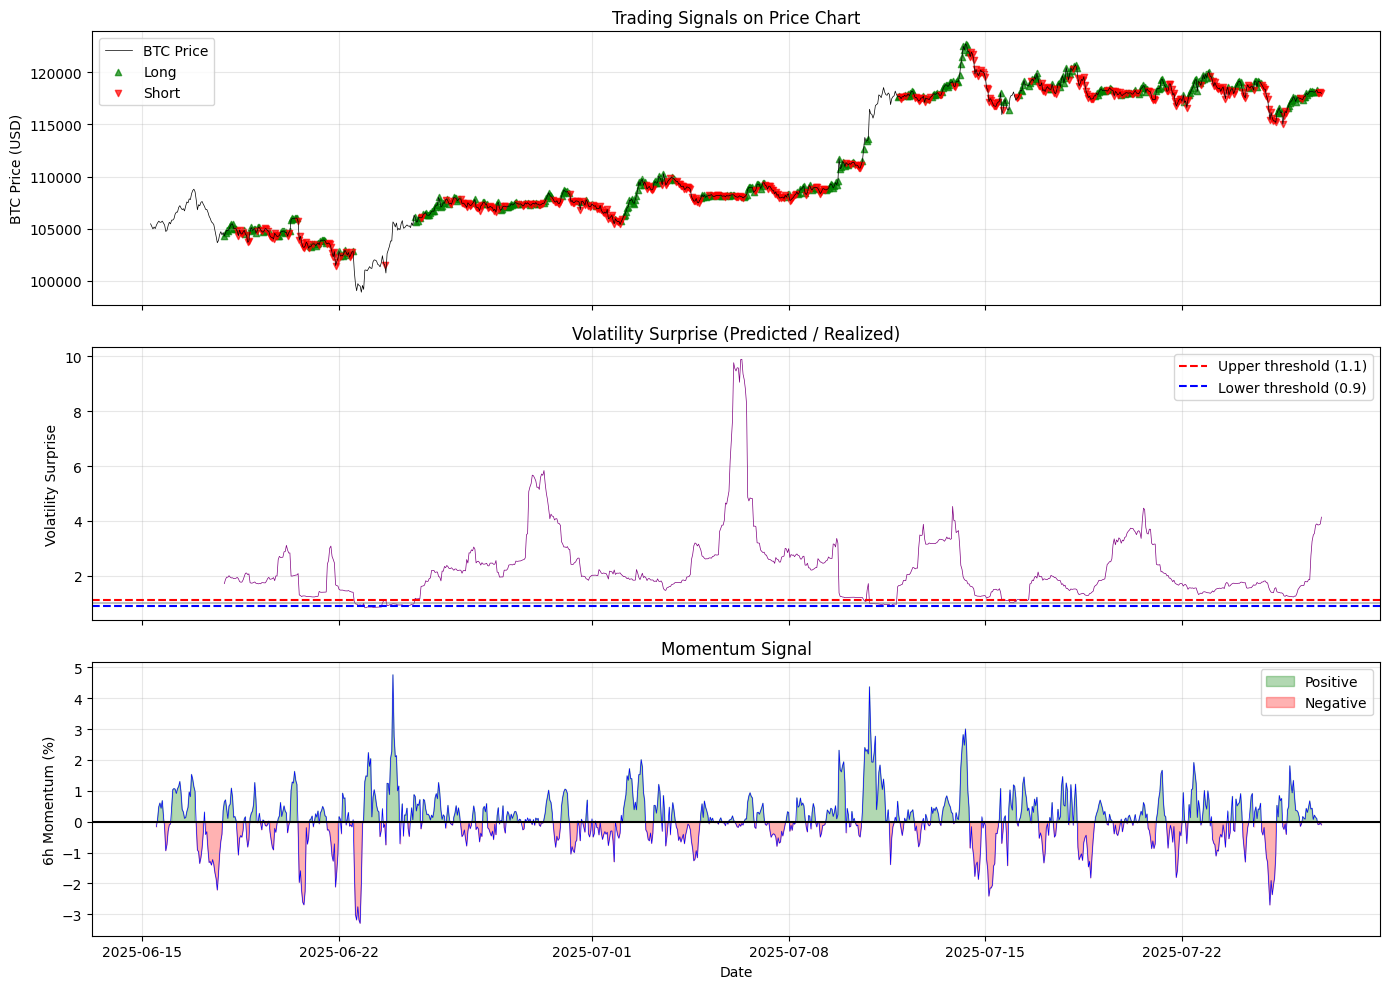

In [ ]:
# =============================================================================
# STEP 3.4: Visualize signals
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Subset for cleaner plotting
plot_df = test_df.iloc[:1000].copy()

# Price with signals
ax = axes[0]
ax.plot(plot_df['datetime'], plot_df['close'], linewidth=0.5, color='black', label='BTC Price')
long_signals = plot_df[plot_df['signal'] == 1]
short_signals = plot_df[plot_df['signal'] == -1]
ax.scatter(long_signals['datetime'], long_signals['close'], color='green', marker='^', s=20, label='Long', alpha=0.7)
ax.scatter(short_signals['datetime'], short_signals['close'], color='red', marker='v', s=20, label='Short', alpha=0.7)
ax.set_ylabel('BTC Price (USD)')
ax.set_title('Trading Signals on Price Chart')
ax.legend()
ax.grid(True, alpha=0.3)

# Volatility surprise
ax = axes[1]
ax.plot(plot_df['datetime'], plot_df['vol_surprise'], linewidth=0.5, color='purple')
ax.axhline(y=VOL_SURPRISE_UPPER, color='red', linestyle='--', label=f'Upper threshold ({VOL_SURPRISE_UPPER})')
ax.axhline(y=1.0, color='gray', linestyle='-', alpha=0.5)
ax.axhline(y=VOL_SURPRISE_LOWER, color='blue', linestyle='--', label=f'Lower threshold ({VOL_SURPRISE_LOWER})')
ax.set_ylabel('Volatility Surprise')
ax.set_title('Volatility Surprise (Predicted / Realized)')
ax.legend()
ax.grid(True, alpha=0.3)

# Momentum
ax = axes[2]
ax.plot(plot_df['datetime'], plot_df['momentum'] * 100, linewidth=0.5, color='blue')
ax.axhline(y=0, color='black', linestyle='-')
ax.fill_between(plot_df['datetime'], 0, plot_df['momentum'] * 100,
                where=plot_df['momentum'] > 0, color='green', alpha=0.3, label='Positive')
ax.fill_between(plot_df['datetime'], 0, plot_df['momentum'] * 100,
                where=plot_df['momentum'] < 0, color='red', alpha=0.3, label='Negative')
ax.set_ylabel(f'{MOMENTUM_LOOKBACK}h Momentum (%)')
ax.set_xlabel('Date')
ax.set_title('Momentum Signal')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 4: Backtesting Engine

### 🎓 Teaching Moment: Realistic Backtesting

A backtest must account for:
1. **Transaction costs** (spreads) - we buy at ask, sell at bid
2. **No lookahead bias** - only use information available at trade time
3. **Position management** - track entry price, holding period, P&L

Our approach:
- **Entry**: At signal, enter at ask (long) or bid (short)
- **Exit**: After holding period OR when signal flips
- **P&L**: Account for spread on both entry AND exit

In [ ]:
# =============================================================================
# STEP 4.1: Backtest function
# =============================================================================

def backtest_strategy(df, holding_period=24, initial_capital=100000):
    """
    Backtest the volatility surprise momentum strategy.

    Parameters:
    -----------
    df : DataFrame with columns: close, signal, spread_pct, estimated_bid, estimated_ask
    holding_period : int, hours to hold each position
    initial_capital : float, starting capital in USD

    Returns:
    --------
    results : dict with trades, equity curve, and metrics
    """

    # Initialize
    trades = []
    equity = initial_capital
    equity_curve = [equity]
    position = 0  # 1 = long, -1 = short, 0 = flat
    entry_price = 0
    entry_time = None
    entry_idx = 0

    df = df.copy().reset_index(drop=True)

    for i in range(len(df)):
        row = df.iloc[i]
        signal = row['signal']

        # Skip if no data
        if pd.isna(signal) or pd.isna(row['close']):
            equity_curve.append(equity)
            continue

        # Check for exit conditions
        should_exit = False
        if position != 0:
            hours_held = i - entry_idx

            # Exit if holding period reached
            if hours_held >= holding_period:
                should_exit = True

            # Exit if signal flips
            if (position == 1 and signal == -1) or (position == -1 and signal == 1):
                should_exit = True

        # Execute exit
        if should_exit and position != 0:
            # Calculate exit price (bid for long, ask for short)
            if position == 1:
                exit_price = row['estimated_bid']  # Sell at bid
            else:
                exit_price = row['estimated_ask']  # Buy back at ask

            # Calculate P&L
            if position == 1:
                pnl_pct = (exit_price - entry_price) / entry_price
            else:  # short
                pnl_pct = (entry_price - exit_price) / entry_price

            pnl_usd = equity * pnl_pct
            equity += pnl_usd

            # Record trade
            trades.append({
                'entry_time': entry_time,
                'exit_time': row['datetime'],
                'entry_price': entry_price,
                'exit_price': exit_price,
                'direction': 'Long' if position == 1 else 'Short',
                'pnl_pct': pnl_pct * 100,
                'pnl_usd': pnl_usd,
                'holding_hours': hours_held
            })

            position = 0

        # Check for entry
        if position == 0 and signal != 0:
            # Enter position
            if signal == 1:
                entry_price = row['estimated_ask']  # Buy at ask
                position = 1
            else:
                entry_price = row['estimated_bid']  # Sell at bid
                position = -1

            entry_time = row['datetime']
            entry_idx = i

        equity_curve.append(equity)

    # Close any open position at end
    if position != 0:
        final_row = df.iloc[-1]
        if position == 1:
            exit_price = final_row['estimated_bid']
            pnl_pct = (exit_price - entry_price) / entry_price
        else:
            exit_price = final_row['estimated_ask']
            pnl_pct = (entry_price - exit_price) / entry_price

        pnl_usd = equity * pnl_pct
        equity += pnl_usd
        equity_curve[-1] = equity

        trades.append({
            'entry_time': entry_time,
            'exit_time': final_row['datetime'],
            'entry_price': entry_price,
            'exit_price': exit_price,
            'direction': 'Long' if position == 1 else 'Short',
            'pnl_pct': pnl_pct * 100,
            'pnl_usd': pnl_usd,
            'holding_hours': len(df) - entry_idx
        })

    return {
        'trades': pd.DataFrame(trades),
        'equity_curve': np.array(equity_curve),
        'final_equity': equity,
        'initial_capital': initial_capital
    }

print("✓ Backtest function defined")

✓ Backtest function defined


In [ ]:
# =============================================================================
# STEP 4.2: Run backtest
# =============================================================================

HOLDING_PERIOD = 24  # hours
INITIAL_CAPITAL = 100000  # USD

# Run backtest
results = backtest_strategy(
    test_df,
    holding_period=HOLDING_PERIOD,
    initial_capital=INITIAL_CAPITAL
)

trades_df = results['trades']
equity_curve = results['equity_curve']

print(f"Backtest completed!")
print(f"  Total trades: {len(trades_df)}")
print(f"  Initial capital: ${INITIAL_CAPITAL:,.0f}")
print(f"  Final equity: ${results['final_equity']:,.0f}")
print(f"  Total return: {(results['final_equity']/INITIAL_CAPITAL - 1)*100:.2f}%")

Backtest completed!
  Total trades: 1081
  Initial capital: $100,000
  Final equity: $40,157
  Total return: -59.84%


---
## Section 5: Performance Metrics

### 🎓 Teaching Moment: Trading Strategy Metrics

| Metric | What It Measures | Good Value |
|--------|-----------------|------------|
| **Total Return** | Overall profit/loss | Positive |
| **Win Rate** | % of profitable trades | > 50% (depends on avg win/loss) |
| **Sharpe Ratio** | Risk-adjusted return | > 1.0 is good, > 2.0 is excellent |
| **Max Drawdown** | Worst peak-to-trough loss | < 20% preferred |
| **Profit Factor** | Gross profit / Gross loss | > 1.5 is good |

In [ ]:
# =============================================================================
# STEP 5.1: Calculate performance metrics
# =============================================================================

def calculate_metrics(trades_df, equity_curve, initial_capital, hours_per_year=8760):
    """
    Calculate comprehensive performance metrics.
    """
    metrics = {}

    # Basic returns
    final_equity = equity_curve[-1]
    total_return = (final_equity / initial_capital - 1) * 100
    metrics['total_return_pct'] = total_return
    metrics['final_equity'] = final_equity

    # Initialize trade statistics with default values
    metrics['num_trades'] = 0
    metrics['win_rate'] = 0.0
    metrics['avg_trade_pnl_pct'] = 0.0
    metrics['avg_win_pct'] = 0.0
    metrics['avg_loss_pct'] = 0.0
    metrics['avg_holding_hours'] = 0.0
    metrics['profit_factor'] = 0.0  # Default to 0.0, will be np.inf if gross_loss is 0
    metrics['num_long'] = 0
    metrics['num_short'] = 0
    metrics['long_win_rate'] = 0.0
    metrics['short_win_rate'] = 0.0

    # Trade statistics
    if len(trades_df) > 0:
        metrics['num_trades'] = len(trades_df)
        metrics['win_rate'] = (trades_df['pnl_pct'] > 0).mean() * 100
        metrics['avg_trade_pnl_pct'] = trades_df['pnl_pct'].mean()
        metrics['avg_win_pct'] = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].mean() if (trades_df['pnl_pct'] > 0).any() else 0
        metrics['avg_loss_pct'] = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].mean() if (trades_df['pnl_pct'] < 0).any() else 0
        metrics['avg_holding_hours'] = trades_df['holding_hours'].mean()

        # Profit factor
        gross_profit = trades_df[trades_df['pnl_usd'] > 0]['pnl_usd'].sum()
        gross_loss = abs(trades_df[trades_df['pnl_usd'] < 0]['pnl_usd'].sum())
        metrics['profit_factor'] = gross_profit / gross_loss if gross_loss > 0 else np.inf

        # Long vs Short breakdown
        long_trades = trades_df[trades_df['direction'] == 'Long']
        short_trades = trades_df[trades_df['direction'] == 'Short']
        metrics['num_long'] = len(long_trades)
        metrics['num_short'] = len(short_trades)
        metrics['long_win_rate'] = (long_trades['pnl_pct'] > 0).mean() * 100 if len(long_trades) > 0 else 0
        metrics['short_win_rate'] = (short_trades['pnl_pct'] > 0).mean() * 100 if len(short_trades) > 0 else 0

    # Equity curve statistics
    metrics['sharpe_ratio'] = 0.0
    metrics['max_drawdown_pct'] = 0.0

    returns = np.diff(equity_curve) / equity_curve[:-1]
    returns = returns[~np.isnan(returns)]  # Remove NaN

    if len(returns) > 0:
        # Sharpe ratio (annualized)
        avg_return = np.mean(returns)
        std_return = np.std(returns)
        if std_return > 0:
            sharpe = (avg_return / std_return) * np.sqrt(hours_per_year)
        else:
            sharpe = 0
        metrics['sharpe_ratio'] = sharpe

        # Max drawdown
        peak = np.maximum.accumulate(equity_curve)
        drawdown = (equity_curve - peak) / peak
        metrics['max_drawdown_pct'] = drawdown.min() * 100

    return metrics

# Calculate metrics
metrics = calculate_metrics(trades_df, equity_curve, INITIAL_CAPITAL)

print("=" * 60)
print("STRATEGY PERFORMANCE METRICS")
print("=" * 60)
print(f"\n📈 Returns:")
print(f"   Total Return:     {metrics['total_return_pct']:.2f}%")
print(f"   Final Equity:     ${metrics['final_equity']:,.0f}")
print(f"   Sharpe Ratio:     {metrics['sharpe_ratio']:.2f}")
print(f"   Max Drawdown:     {metrics['max_drawdown_pct']:.2f}%")

print(f"\n📊 Trade Statistics:")
print(f"   Total Trades:     {metrics['num_trades']}")
print(f"   Win Rate:         {metrics['win_rate']:.1f}%")
print(f"   Avg Trade P&L:    {metrics['avg_trade_pnl_pct']:.3f}%")
print(f"   Avg Win:          {metrics['avg_win_pct']:.3f}%")
print(f"   Avg Loss:         {metrics['avg_loss_pct']:.3f}%")
print(f"   Profit Factor:    {metrics['profit_factor']:.2f}")
print(f"   Avg Holding:      {metrics['avg_holding_hours']:.1f} hours")

print(f"\n📉 Long vs Short:")
print(f"   Long Trades:      {metrics['num_long']} (win rate: {metrics['long_win_rate']:.1f}%)的发展" if metrics['num_long'] > 0 else f"   Long Trades:      {metrics['num_long']}")
print(f"   Short Trades:     {metrics['num_short']} (win rate: {metrics['short_win_rate']:.1f}%)的发展" if metrics['num_short'] > 0 else f"   Short Trades:     {metrics['num_short']}")

STRATEGY PERFORMANCE METRICS

📈 Returns:
   Total Return:     -59.84%
   Final Equity:     $40,157
   Sharpe Ratio:     -3.03
   Max Drawdown:     -66.43%

📊 Trade Statistics:
   Total Trades:     1081
   Win Rate:         27.2%
   Avg Trade P&L:    -0.080%
   Avg Win:          0.931%
   Avg Loss:         -0.457%
   Profit Factor:    0.73
   Avg Holding:      5.7 hours

📉 Long vs Short:
   Long Trades:      538 (win rate: 26.8%)的发展
   Short Trades:     543 (win rate: 27.6%)的发展


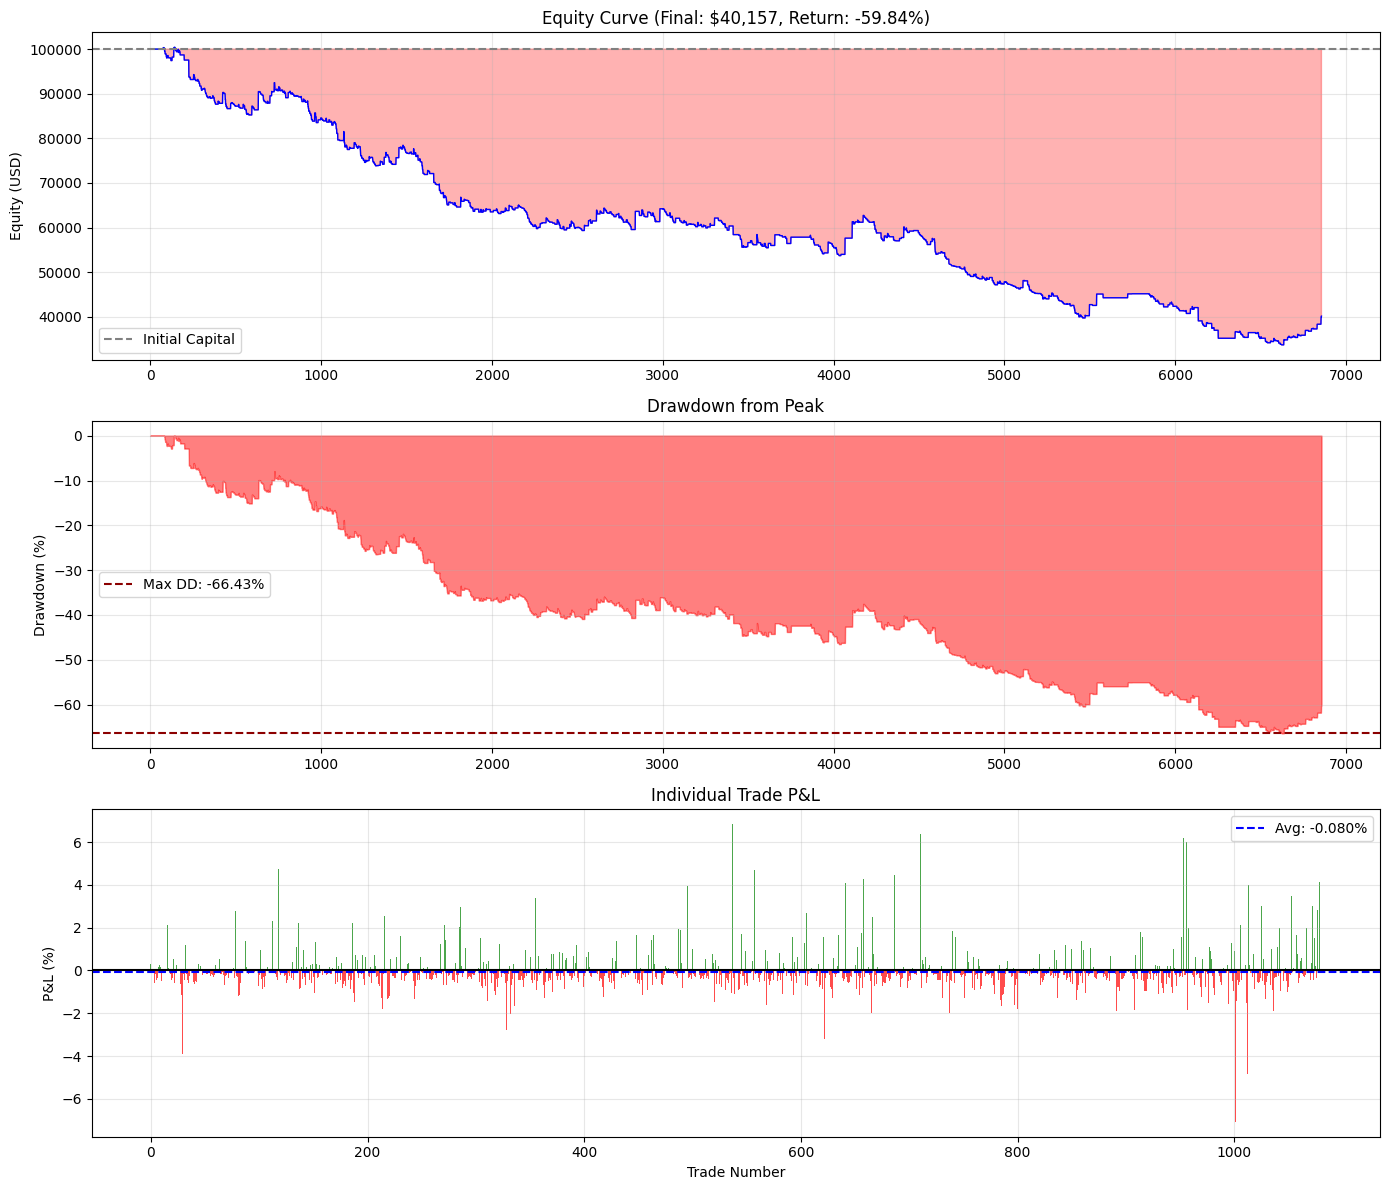

In [ ]:
# =============================================================================
# STEP 5.2: Visualize equity curve and drawdown
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Equity curve
ax = axes[0]
ax.plot(equity_curve, linewidth=1, color='blue')
ax.axhline(y=INITIAL_CAPITAL, color='gray', linestyle='--', label='Initial Capital')
ax.fill_between(range(len(equity_curve)), INITIAL_CAPITAL, equity_curve,
                where=equity_curve >= INITIAL_CAPITAL, color='green', alpha=0.3)
ax.fill_between(range(len(equity_curve)), INITIAL_CAPITAL, equity_curve,
                where=equity_curve < INITIAL_CAPITAL, color='red', alpha=0.3)
ax.set_ylabel('Equity (USD)')
ax.set_title(f'Equity Curve (Final: ${equity_curve[-1]:,.0f}, Return: {metrics["total_return_pct"]:+.2f}%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Drawdown
ax = axes[1]
peak = np.maximum.accumulate(equity_curve)
drawdown = (equity_curve - peak) / peak * 100
ax.fill_between(range(len(drawdown)), 0, drawdown, color='red', alpha=0.5)
ax.axhline(y=metrics['max_drawdown_pct'], color='darkred', linestyle='--',
           label=f'Max DD: {metrics["max_drawdown_pct"]:.2f}%')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown from Peak')
ax.legend()
ax.grid(True, alpha=0.3)

# Trade P&L distribution
ax = axes[2]
if len(trades_df) > 0:
    colors = ['green' if x > 0 else 'red' for x in trades_df['pnl_pct']]
    ax.bar(range(len(trades_df)), trades_df['pnl_pct'], color=colors, alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-')
    ax.axhline(y=trades_df['pnl_pct'].mean(), color='blue', linestyle='--',
               label=f'Avg: {trades_df["pnl_pct"].mean():+.3f}%')
ax.set_xlabel('Trade Number')
ax.set_ylabel('P&L (%)')
ax.set_title('Individual Trade P&L')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Comparison with Baselines

### 🎓 Teaching Moment: Is the Model Adding Value?

To know if our model is useful, we compare against:
1. **Buy and Hold**: Just buy BTC at start, hold until end
2. **Random Signals**: Same trading frequency but random direction

If our strategy beats random signals, the model is adding value!

In [ ]:
# =============================================================================
# STEP 6.1: Buy and Hold baseline
# =============================================================================

# Buy at first price, sell at last price (accounting for spread)
first_valid_idx = test_df['estimated_ask'].first_valid_index()
last_valid_idx = test_df['estimated_bid'].last_valid_index()

entry_price_bh = test_df.loc[first_valid_idx, 'estimated_ask']
exit_price_bh = test_df.loc[last_valid_idx, 'estimated_bid']

buy_hold_return = (exit_price_bh / entry_price_bh - 1) * 100

print(f"Buy and Hold Baseline:")
print(f"  Entry price: ${entry_price_bh:,.2f}")
print(f"  Exit price:  ${exit_price_bh:,.2f}")
print(f"  Return:      {buy_hold_return:+.2f}%")

Buy and Hold Baseline:
  Entry price: $105,511.98
  Exit price:  $66,361.10
  Return:      -37.11%


In [ ]:
# =============================================================================
# STEP 6.2: Random signals baseline (Monte Carlo)
# =============================================================================

# 🎓 Teaching Moment: Monte Carlo Simulation
#
# We run the strategy many times with random signals (same frequency)
# to see what returns we'd get by chance.
# If our strategy beats most random runs, the model is adding value.

def generate_random_signals(df, trade_frequency):
    """
    Generate random signals with same frequency as actual strategy.
    """
    n = len(df)
    n_trades = int(n * trade_frequency)

    signals = np.zeros(n)
    trade_indices = np.random.choice(n, size=n_trades, replace=False)
    signals[trade_indices] = np.random.choice([1, -1], size=n_trades)

    return signals

# Actual trade frequency
actual_trade_freq = (test_df['signal'] != 0).mean()
print(f"Actual trade frequency: {actual_trade_freq*100:.1f}%")

# Run Monte Carlo
N_SIMULATIONS = 100
random_returns = []

print(f"\nRunning {N_SIMULATIONS} random signal simulations...")

for i in range(N_SIMULATIONS):
    # Generate random signals
    test_df_random = test_df.copy()
    test_df_random['signal'] = generate_random_signals(test_df, actual_trade_freq)

    # Run backtest
    random_results = backtest_strategy(
        test_df_random,
        holding_period=HOLDING_PERIOD,
        initial_capital=INITIAL_CAPITAL
    )

    random_return = (random_results['final_equity'] / INITIAL_CAPITAL - 1) * 100
    random_returns.append(random_return)

random_returns = np.array(random_returns)

print(f"\nRandom Signal Baseline (n={N_SIMULATIONS}):")
print(f"  Mean return:   {random_returns.mean():+.2f}%")
print(f"  Median return: {np.median(random_returns):+.2f}%")
print(f"  Std return:    {random_returns.std():.2f}%")
print(f"  Range:         [{random_returns.min():+.2f}%, {random_returns.max():+.2f}%]")

Actual trade frequency: 76.8%

Running 100 random signal simulations...

Random Signal Baseline (n=100):
  Mean return:   -97.37%
  Median return: -97.61%
  Std return:    0.99%
  Range:         [-99.02%, -94.97%]


In [ ]:
# =============================================================================
# STEP 6.3: Statistical comparison
# =============================================================================

strategy_return = metrics['total_return_pct']

# Percentile rank vs random
percentile = (random_returns < strategy_return).mean() * 100

# Z-score
z_score = (strategy_return - random_returns.mean()) / random_returns.std() if random_returns.std() > 0 else 0

print("=" * 60)
print("STRATEGY vs BASELINES")
print("=" * 60)
print(f"\n{'Baseline':<25} {'Return':>12}")
print("-" * 40)
print(f"{'Buy and Hold':<25} {buy_hold_return:>+12.2f}%")
print(f"{'Random Signals (avg)':<25} {random_returns.mean():>+12.2f}%")
print(f"{'Our Strategy':<25} {strategy_return:>+12.2f}%")
print("-" * 40)

print(f"\n📊 Statistical Significance:")
print(f"   Percentile vs Random: {percentile:.1f}%")
print(f"   Z-Score vs Random:    {z_score:+.2f}")

if percentile > 95:
    print(f"\n✅ Strategy significantly outperforms random (p < 0.05)!")
elif percentile > 75:
    print(f"\n⚠️ Strategy slightly better than random, but not statistically significant.")
else:
    print(f"\n❌ Strategy does not outperform random signals.")

STRATEGY vs BASELINES

Baseline                        Return
----------------------------------------
Buy and Hold                    -37.11%
Random Signals (avg)            -96.89%
Our Strategy                    -59.84%
----------------------------------------

📊 Statistical Significance:
   Percentile vs Random: 100.0%
   Z-Score vs Random:    +26.42

✅ Strategy significantly outperforms random (p < 0.05)!


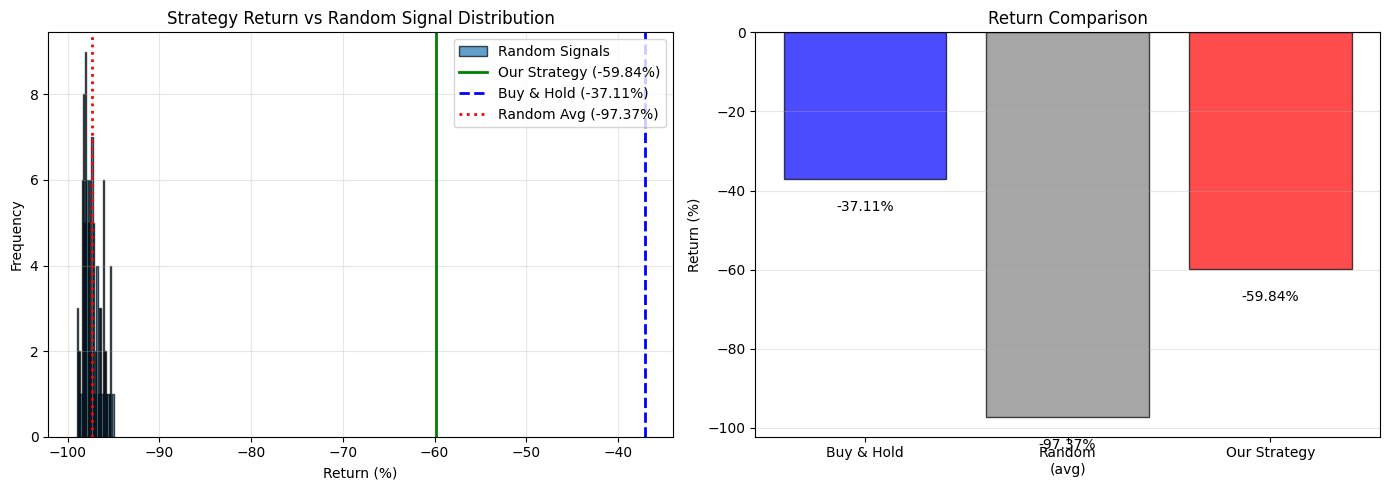

In [ ]:
# =============================================================================
# STEP 6.4: Visualization of comparison
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of random returns
ax = axes[0]
ax.hist(random_returns, bins=30, edgecolor='black', alpha=0.7, label='Random Signals')
ax.axvline(x=strategy_return, color='green', linewidth=2, linestyle='-',
           label=f'Our Strategy ({strategy_return:+.2f}%)')
ax.axvline(x=buy_hold_return, color='blue', linewidth=2, linestyle='--',
           label=f'Buy & Hold ({buy_hold_return:+.2f}%)')
ax.axvline(x=random_returns.mean(), color='red', linewidth=2, linestyle=':',
           label=f'Random Avg ({random_returns.mean():+.2f}%)')
ax.set_xlabel('Return (%)')
ax.set_ylabel('Frequency')
ax.set_title('Strategy Return vs Random Signal Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Bar comparison
ax = axes[1]
baselines = ['Buy & Hold', 'Random\n(avg)', 'Our Strategy']
returns = [buy_hold_return, random_returns.mean(), strategy_return]
colors = ['blue', 'gray', 'green' if strategy_return > 0 else 'red']
bars = ax.bar(baselines, returns, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-')
ax.set_ylabel('Return (%)')
ax.set_title('Return Comparison')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, ret in zip(bars, returns):
    height = bar.get_height()
    ax.annotate(f'{ret:+.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -15),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

---
## Section 7: Spread Impact Analysis

### 🎓 Teaching Moment: Transaction Costs Kill Strategies

Many strategies that look profitable without costs become unprofitable with realistic spreads.
Let's see how much spreads cost us.

In [ ]:
# =============================================================================
# STEP 7.1: Run backtest without spreads (using mid price)
# =============================================================================

# Create version with zero spread
test_df_no_spread = test_df.copy()
test_df_no_spread['estimated_bid'] = test_df_no_spread['close']
test_df_no_spread['estimated_ask'] = test_df_no_spread['close']

# Run backtest
results_no_spread = backtest_strategy(
    test_df_no_spread,
    holding_period=HOLDING_PERIOD,
    initial_capital=INITIAL_CAPITAL
)

return_no_spread = (results_no_spread['final_equity'] / INITIAL_CAPITAL - 1) * 100
return_with_spread = metrics['total_return_pct']
spread_impact = return_no_spread - return_with_spread

print("=" * 60)
print("SPREAD IMPACT ANALYSIS")
print("=" * 60)
print(f"\nReturn WITHOUT spreads: {return_no_spread:+.2f}%")
print(f"Return WITH spreads:    {return_with_spread:+.2f}%")
print(f"Spread cost:            {spread_impact:.2f}%")
print(f"\nSpread cost per trade:  {spread_impact/metrics['num_trades']*100:.3f} bps")
print(f"Average spread used:    {test_df['spread_bps'].mean():.1f} bps")

SPREAD IMPACT ANALYSIS

Return WITHOUT spreads: +38.43%
Return WITH spreads:    -59.84%
Spread cost:            98.28%

Spread cost per trade:  9.091 bps
Average spread used:    13.3 bps


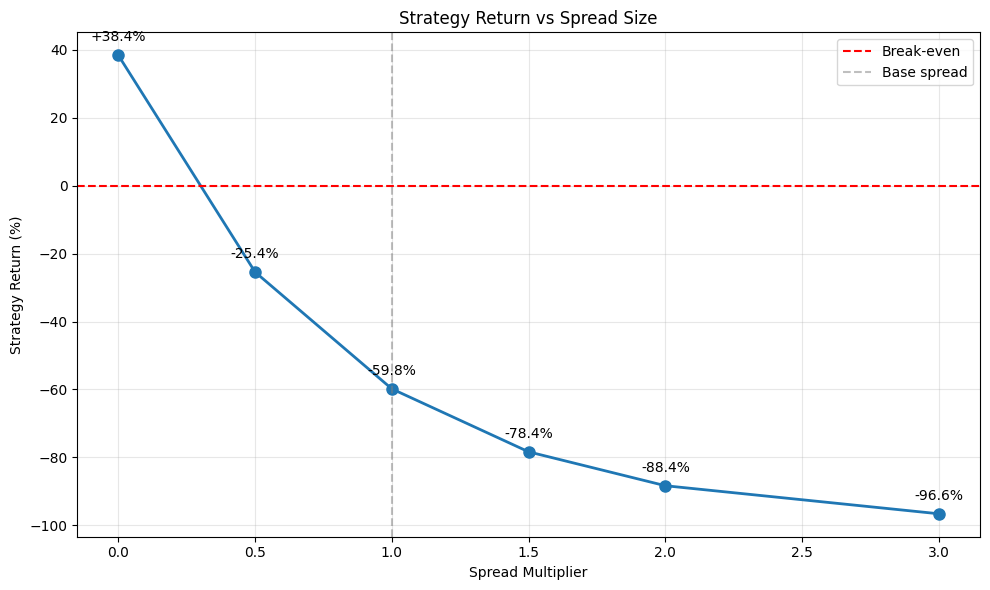


📊 Spread Sensitivity:
  0.0x spread (0.0 bps): +38.43%
  0.5x spread (6.7 bps): -25.42%
  1.0x spread (13.3 bps): -59.84%
  1.5x spread (20.0 bps): -78.39%
  2.0x spread (26.6 bps): -88.37%
  3.0x spread (40.0 bps): -96.64%


In [ ]:
# =============================================================================
# STEP 7.2: Sensitivity to spread size
# =============================================================================

spread_multipliers = [0, 0.5, 1.0, 1.5, 2.0, 3.0]
spread_returns = []

for mult in spread_multipliers:
    test_df_scaled = test_df.copy()

    # Scale spread
    half_spread = test_df['spread_pct'] / 100 / 2 * mult
    test_df_scaled['estimated_bid'] = test_df['close'] * (1 - half_spread)
    test_df_scaled['estimated_ask'] = test_df['close'] * (1 + half_spread)

    # Run backtest
    results_scaled = backtest_strategy(
        test_df_scaled,
        holding_period=HOLDING_PERIOD,
        initial_capital=INITIAL_CAPITAL
    )

    ret = (results_scaled['final_equity'] / INITIAL_CAPITAL - 1) * 100
    spread_returns.append(ret)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(spread_multipliers, spread_returns, 'o-', linewidth=2, markersize=8)
ax.axhline(y=0, color='red', linestyle='--', label='Break-even')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Base spread')
ax.set_xlabel('Spread Multiplier')
ax.set_ylabel('Strategy Return (%)')
ax.set_title('Strategy Return vs Spread Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate
for mult, ret in zip(spread_multipliers, spread_returns):
    ax.annotate(f'{ret:+.1f}%', (mult, ret), textcoords="offset points",
                xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

print("\n📊 Spread Sensitivity:")
for mult, ret in zip(spread_multipliers, spread_returns):
    avg_spread = test_df['spread_bps'].mean() * mult
    print(f"  {mult:.1f}x spread ({avg_spread:.1f} bps): {ret:+.2f}%")

---
## Section 8: Save Results

In [ ]:
# =============================================================================
# STEP 8.1: Save backtest results
# =============================================================================

# Save trades
trades_df.to_csv(f'{DATA_DIR}/backtest_trades.csv', index=False)

# Save metrics
results_summary = {
    'strategy_metrics': metrics,
    'baselines': {
        'buy_hold_return': buy_hold_return,
        'random_mean_return': float(random_returns.mean()),
        'random_std_return': float(random_returns.std())
    },
    'spread_analysis': {
        'return_no_spread': return_no_spread,
        'return_with_spread': return_with_spread,
        'spread_impact': spread_impact
    },
    'strategy_params': {
        'vol_surprise_upper': VOL_SURPRISE_UPPER,
        'vol_surprise_lower': VOL_SURPRISE_LOWER,
        'momentum_lookback': MOMENTUM_LOOKBACK,
        'holding_period': HOLDING_PERIOD
    }
}

with open(f'{DATA_DIR}/backtest_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=float)

print(f"✓ Results saved to {DATA_DIR}")
print(f"  - backtest_trades.csv")
print(f"  - backtest_results.json")

✓ Results saved to /content/drive/MyDrive/btc_volatility_project
  - backtest_trades.csv
  - backtest_results.json


---
## Section 9: Summary and Interpretation

In [ ]:
# =============================================================================
# Final Summary
# =============================================================================

print("=" * 60)
print("BACKTEST SUMMARY: VOLATILITY SURPRISE MOMENTUM")
print("=" * 60)

print(f"\n📋 Strategy Parameters:")
print(f"   Vol Surprise Threshold: > {VOL_SURPRISE_UPPER} (expect 10%+ more vol)")
print(f"   Momentum Lookback:      {MOMENTUM_LOOKBACK} hours")
print(f"   Holding Period:         {HOLDING_PERIOD} hours")

print(f"\n📈 Performance:")
print(f"   Total Return:   {metrics['total_return_pct']:+.2f}%")
print(f"   Sharpe Ratio:   {metrics['sharpe_ratio']:.2f}")
print(f"   Max Drawdown:   {metrics['max_drawdown_pct']:.2f}%")
print(f"   Win Rate:       {metrics['win_rate']:.1f}%")
print(f"   Profit Factor:  {metrics['profit_factor']:.2f}")

print(f"\n🔄 vs Baselines:")
print(f"   Buy & Hold:     {buy_hold_return:+.2f}%")
print(f"   Random Signals: {random_returns.mean():+.2f}% (avg)")
print(f"   Percentile:     {percentile:.0f}th (vs random)")

print(f"\n💰 Spread Impact:")
print(f"   Without Spread: {return_no_spread:+.2f}%")
print(f"   With Spread:    {return_with_spread:+.2f}%")
print(f"   Cost of Spread: {spread_impact:.2f}%")

print(f"\n🚀 Next Steps (Week 4 MCP Agent):")
print(f"   - Wrap model + strategy as MCP tools")
print(f"   - Build Observe→Plan→Act→Learn loop")
print(f"   - Add memory for trade tracking")

BACKTEST SUMMARY: VOLATILITY SURPRISE MOMENTUM

📋 Strategy Parameters:
   Vol Surprise Threshold: > 1.1 (expect 10%+ more vol)
   Momentum Lookback:      6 hours
   Holding Period:         24 hours

📈 Performance:
   Total Return:   -59.84%
   Sharpe Ratio:   -3.03
   Max Drawdown:   -66.43%
   Win Rate:       27.2%
   Profit Factor:  0.73

🔄 vs Baselines:
   Buy & Hold:     -37.11%
   Random Signals: -97.37% (avg)
   Percentile:     100th (vs random)

💰 Spread Impact:
   Without Spread: +38.43%
   With Spread:    -59.84%
   Cost of Spread: 98.28%

🚀 Next Steps (Week 4 MCP Agent):
   - Wrap model + strategy as MCP tools
   - Build Observe→Plan→Act→Learn loop
   - Add memory for trade tracking


---
## 🎓 Key Learnings from This Notebook

1. **Signal Generation**: Converting model predictions to trading signals requires additional logic (thresholds, momentum filters)

2. **Realistic Backtesting**: Always account for transaction costs (spreads)!

3. **Baseline Comparison**: Compare against:
   - Buy & Hold (is active trading worth it?)
   - Random signals (is the model adding value?)

4. **Statistical Significance**: Monte Carlo simulation helps determine if results are luck or skill

5. **Spread Sensitivity**: Many strategies become unprofitable with realistic costs

---

### Interpretation Guide

| Result | Interpretation |
|--------|---------------|
| **Strategy beats random (>95th percentile)** | Model is adding predictive value |
| **Strategy beats buy & hold** | Active trading worthwhile |
| **Sharpe > 1** | Good risk-adjusted returns |
| **Spread impact > gross return** | Strategy not viable with real costs |

**Remember**: For learning purposes, building the complete pipeline is the goal!
Professional-grade strategies require much more refinement.